In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))  # go up two levels (from numerics to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# # Ensure packages are installed
# for pkg in [
#     "PauliPropagation", "Plots", "LinearAlgebra", "ProgressMeter", "Distributions",
#     "Random", "Optimisers", "ReverseDiff", "MAT", "BenchmarkTools", "IterTools", "StatsBase", "LaTeXStrings", "Measures", "CSV", "DataFrames", "JSON3", "Dates"
# ]
#     Pkg.add(pkg)
# end

In [3]:
# Load all packages
using PauliSampling, PauliPropagation, Plots, LinearAlgebra, ProgressMeter, Statistics, Printf, Distributions, Random, Optimisers, ReverseDiff, MAT, BenchmarkTools, IterTools, StatsBase, LaTeXStrings, Measures, CSV, DataFrames, JSON3, Dates

## Target state

In [4]:
nq = 6 
target_beta = 2

target_interaction = 0.346
target_field = 0.822

params_target = parameters(:tfim, nq; field_vals=Dict(:X => -target_field), coupling_vals=Dict(:ZZ => target_interaction))
target_tfim_paulis = makehamiltonian(params_target; connectivity=:nearest, periodic=false) * target_beta
target_tfim_matrix = paulistringtomatrix(target_tfim_paulis);

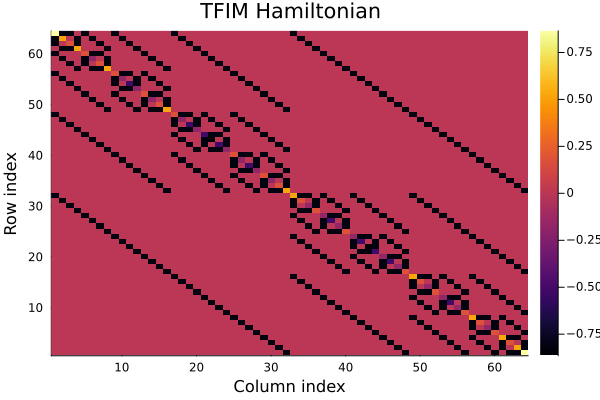

In [5]:
heatmap(reverse(real(target_tfim_matrix); dims=1),
        xlabel="Column index",
        ylabel="Row index",
        title="TFIM Hamiltonian"
        )

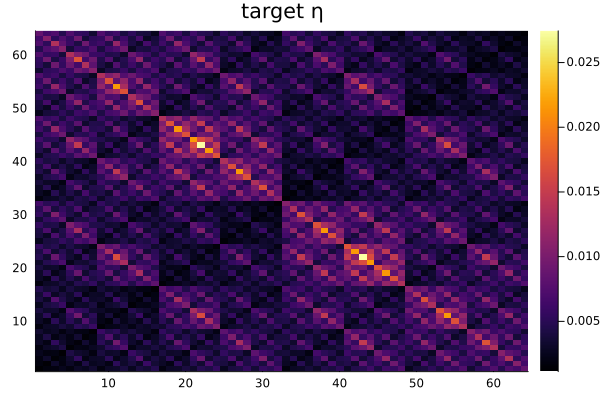

In [6]:
targert_circuit, θ = paulistringtocircuit(target_tfim_paulis)

num_layers = 100
max_weight = nq
min_abs_coeff = 1e-20
target_eta = makethermalstate(nq, targert_circuit, θ, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
target_eta_matrix = paulistringtomatrix(target_eta)

heatmap(reverse(real(target_eta_matrix); dims=1), title="target η")

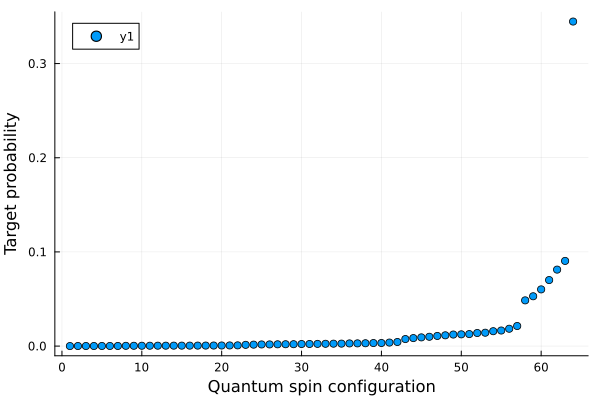

In [7]:
target_probs = computesymmetriceigenvalues(target_eta_matrix);
scatter(target_probs, ylabel="Target probability", xlabel="Quantum spin configuration")

## Model QBM

In [8]:
# parameters to learn. Set initial values at random
rng = MersenneTwister(1)
jz = 0.330
bx = -1.303
@printf("Spin interactions: %f\n", jz)
@printf("Field values: %f\n", bx)

Spin interactions: 0.330000
Field values: -1.303000


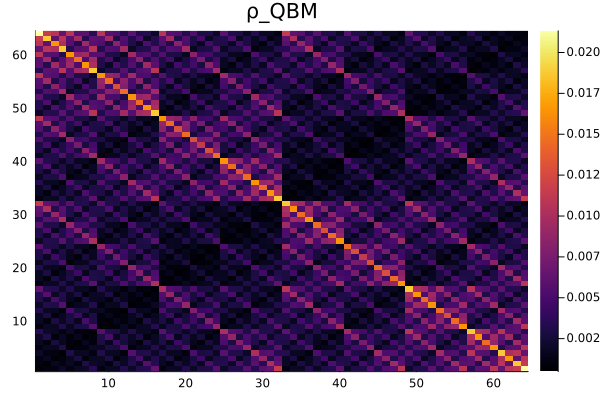

In [9]:
beta = -1    
params = parameters(:tfim, nq; field_vals=Dict(:X => -bx), coupling_vals=Dict(:ZZ => jz))

qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, theta = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
max_weight = nq
min_abs_coeff = 1e-20
qbm = makethermalstate(nq, circuit, theta, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

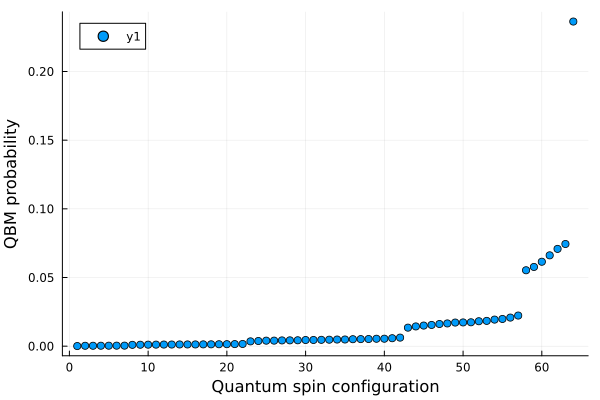

In [10]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(rho_probs, marker=:circle, ylabel="QBM probability", xlabel="Quantum spin configuration")

### Cost function: quantum relative entropy

$$S(\eta \| \rho_\theta) = \operatorname{Tr}[\eta \log \eta]-\operatorname{Tr}\left[\eta \log \rho_\theta\right]$$

In [11]:
computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix)

0.15639997710520603

### Gradient of quantum relative entropy

Given $H_\theta = \sum_i \theta_i H_i$ and the QBM $\rho_\theta = \frac{e^{-\beta H_\theta}}{\operatorname{Tr}[e^{-\beta H_\theta}]}$, the gradient of the cost function (quantum relative entropy) is given by

$$\partial_{\theta_i} S(\eta \| \rho_\theta) = \operatorname{Tr}[H_i \eta] -  \operatorname{Tr}[H_i \rho_\theta]$$

(see Eq. (8) in Tüysüz, Cenk, et al. "Learning to generate high-dimensional distributions with low-dimensional quantum Boltzmann machines." arXiv preprint arXiv:2410.16363 (2024))

In [12]:
qbm_tfim_paulis

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.6515 * XIIIII)
 PauliString(nqubits: 6, -0.6515 * IXIIII)
 PauliString(nqubits: 6, -0.6515 * IIXIII)
 PauliString(nqubits: 6, -0.6515 * IIIXII)
 PauliString(nqubits: 6, -0.6515 * IIIIXI)
 PauliString(nqubits: 6, -0.6515 * IIIIIX)
 PauliString(nqubits: 6, -0.0825 * ZZIIII)
 PauliString(nqubits: 6, -0.0825 * IZZIII)
 PauliString(nqubits: 6, -0.0825 * IIZZII)
 PauliString(nqubits: 6, -0.0825 * IIIZZI)
 PauliString(nqubits: 6, -0.0825 * IIIIZZ)

In [25]:
grads = computegradients(qbm_tfim_paulis, target_eta, qbm)
println("Gradients: ", grads)

Gradients: [1.702543661608047e-10, 3.5916303264826865e-10, 3.773630297132513e-10, 3.7736364033591485e-10, 3.591623665144539e-10, 1.7025270082626776e-10, -8.401585191442074e-10, -9.394987253441567e-10, -9.444726424556737e-10, -9.394987218747097e-10, -8.401583838357762e-10]


# Training of the QBM 

In [16]:
# --- Initialization ---
qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta

# learning rate
gamma = 0.2
# number of epochs
epochs = 2000
# stop when gradient is smaller than epsilon, at the final number of epochs
epsilon = 1e-9
# keep track of loss and gradients
qre_hist = Float64[]
grad_hist = Vector{Float64}[]

for epoch in 1:epochs
    # Build Hamiltonian matrix
    qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
    push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

    # Create thermal state
    circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
    num_layers = 100
    max_weight = nq
    min_abs_coeff = 1e-10
    rho = makethermalstate(nq, circuit, theta, num_layers;
                            max_weight=max_weight, min_abs_coeff=min_abs_coeff)
    rho_matrix = paulistringtomatrix(rho)

    # --- Gradient computation (efficient) ---
    grads = computegradients(qbm_tfim_paulis, target_eta, rho)
    push!(grad_hist, abs.(grads))

    # --- Parameter update ---
    updatehamiltonian!(qbm_tfim_paulis, grads, gamma)

    # --- Diagnostics ---
    if epoch % 100 == 0
        @printf("\nEpoch %d\n", epoch)
        @printf("  Quantum relative entropy: %.6f\n", qre_hist[end])
        @printf("  Max abs gradient:         %.6f\n", maximum(grad_hist[end]))
    end

    # --- Convergence ---
    if maximum(grad_hist[end]) < epsilon
        println("Converged: max gradient < epsilon")
        break
    end
end


Epoch 100
  Quantum relative entropy: 0.000135
  Max abs gradient:         0.001507

Epoch 200
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000058

Epoch 300
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000002

Epoch 400
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000000

Epoch 500
  Quantum relative entropy: 0.000001
  Max abs gradient:         0.000000
Converged: max gradient < epsilon


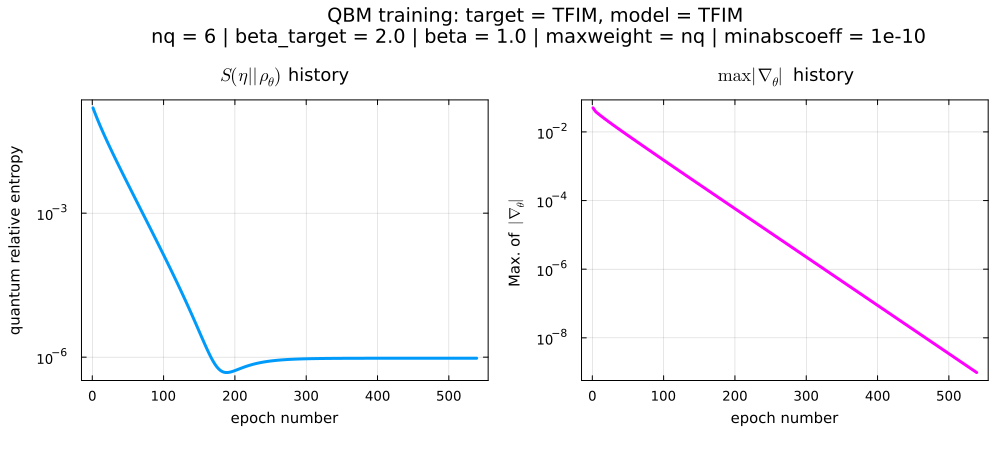

In [17]:
gr()

# ---- First plot ----
p1 = plot(qre_hist,
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = false,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Second plot ----
p2 = plot([maximum(g) for g in grad_hist],
    yaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),  
    legend = false,
    color = :fuchsia,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm)

# ---- Combine side by side ----
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = TFIM, model = TFIM\n nq = 6 | beta_target = 2.0 | beta = 1.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm       
)

display(combined)

## Compare the final parameters with the target parameters.

**Note** the Hamiltonian is the same but the target state was created with $\beta = 2 $ and we use a QBM with $\beta = 1$.

In [18]:
@printf("Original target hamiltonian:")
target_tfim_paulis

Original target hamiltonian:

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.822 * XIIIII)
 PauliString(nqubits: 6, -0.822 * IXIIII)
 PauliString(nqubits: 6, -0.822 * IIXIII)
 PauliString(nqubits: 6, -0.822 * IIIXII)
 PauliString(nqubits: 6, -0.822 * IIIIXI)
 PauliString(nqubits: 6, -0.822 * IIIIIX)
 PauliString(nqubits: 6, 0.173 * ZZIIII)
 PauliString(nqubits: 6, 0.173 * IZZIII)
 PauliString(nqubits: 6, 0.173 * IIZZII)
 PauliString(nqubits: 6, 0.173 * IIIZZI)
 PauliString(nqubits: 6, 0.173 * IIIIZZ)

In [19]:
@printf("Learnt hamiltonian:")
qbm_tfim_paulis

Learnt hamiltonian:

11-element Vector{PauliString{UInt16, Float64}}:
 PauliString(nqubits: 6, -0.822 * XIIIII)
 PauliString(nqubits: 6, -0.822 * IXIIII)
 PauliString(nqubits: 6, -0.822 * IIXIII)
 PauliString(nqubits: 6, -0.822 * IIIXII)
 PauliString(nqubits: 6, -0.822 * IIIIXI)
 PauliString(nqubits: 6, -0.822 * IIIIIX)
 PauliString(nqubits: 6, 0.173 * ZZIIII)
 PauliString(nqubits: 6, 0.173 * IZZIII)
 PauliString(nqubits: 6, 0.173 * IIZZII)
 PauliString(nqubits: 6, 0.173 * IIIZZI)
 PauliString(nqubits: 6, 0.173 * IIIIZZ)

Compare the "images" of the target and trained QBM density matrices

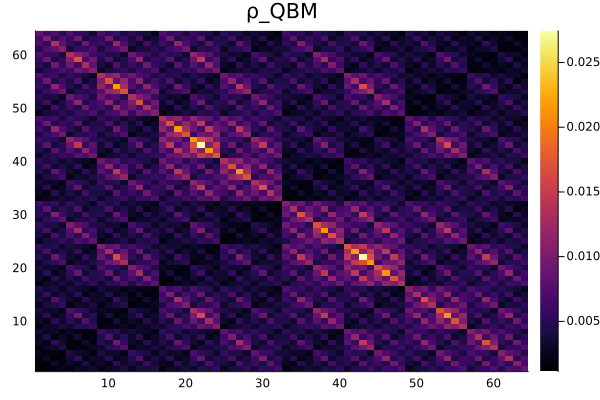

In [20]:
qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)

circuit, angles = paulistringtocircuit(qbm_tfim_paulis)

num_layers = 100
max_weight = nq
min_abs_coeff = 1e-10
qbm = makethermalstate(nq, circuit, angles, num_layers;
                                  max_weight=max_weight,
                                  min_abs_coeff=min_abs_coeff)
qbm_matrix = paulistringtomatrix(qbm)

heatmap(reverse(real(qbm_matrix); dims=1), title="ρ_QBM")

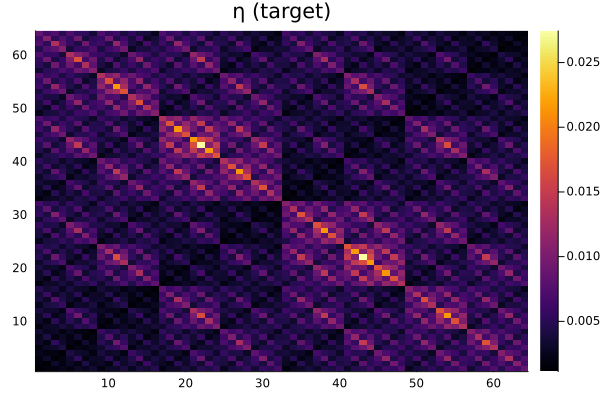

In [21]:
heatmap(reverse(real(target_eta_matrix); dims=1), title="η (target)")

A way to compare the two density matrices is to compute the fidelity between them. A fidelity close to 1 means the two quantum states are the same

In [22]:
# Uhlmann fidelity (squared) between density matrices
function fidelity(ρ::AbstractMatrix, σ::AbstractMatrix)
    F = 0.0
    # sqrt(ρ)
    evals, evecs = eigen(Hermitian(ρ))
    sqrtρ = evecs * Diagonal(sqrt.(clamp.(evals, 0, Inf))) * evecs'
    A = sqrtρ * σ * sqrtρ
    evalsA = computesymmetriceigenvalues(A)
    rootF = sum(sqrt.(clamp.(evalsA, 0, Inf)))
    (rootF)^2
end

fidelity (generic function with 1 method)

In [23]:
# fidelity
F = fidelity(target_eta_matrix, qbm_matrix)
F

1.000000000000031

We can also plot the probability distributions:

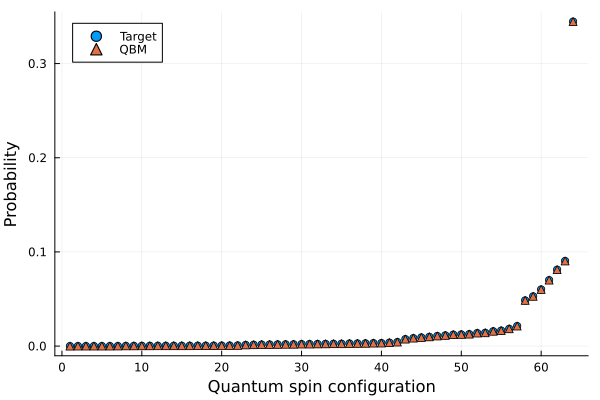

In [24]:
rho_probs = computesymmetriceigenvalues(qbm_matrix)
scatter(1:length(rho_probs), target_probs, label="Target", marker=:circle, xlabel="Quantum spin configuration", ylabel="Probability")
scatter!(1:length(rho_probs), rho_probs, label="QBM", marker=:utriangle)

### Different temperatures


Starting optimization for β = 0.050
  [β=0.05 | epoch= 100]  QRE = 9.327294e-01   max|∇| = 2.536676e-01
  [β=0.05 | epoch= 200]  QRE = 6.245176e-01   max|∇| = 1.999828e-01
  [β=0.05 | epoch= 300]  QRE = 4.298332e-01   max|∇| = 1.596377e-01
  [β=0.05 | epoch= 400]  QRE = 3.035217e-01   max|∇| = 1.290155e-01
  [β=0.05 | epoch= 500]  QRE = 2.194307e-01   max|∇| = 1.054369e-01
  [β=0.05 | epoch= 600]  QRE = 1.621149e-01   max|∇| = 8.700647e-02
  [β=0.05 | epoch= 700]  QRE = 1.222129e-01   max|∇| = 7.239469e-02
  [β=0.05 | epoch= 800]  QRE = 9.389826e-02   max|∇| = 6.066206e-02
  [β=0.05 | epoch= 900]  QRE = 7.345211e-02   max|∇| = 5.113552e-02
  [β=0.05 | epoch=1000]  QRE = 5.844621e-02   max|∇| = 4.332499e-02
  [β=0.05 | epoch=1100]  QRE = 4.726248e-02   max|∇| = 3.686761e-02
  [β=0.05 | epoch=1200]  QRE = 3.880318e-02   max|∇| = 3.149042e-02
  [β=0.05 | epoch=1300]  QRE = 3.231168e-02   max|∇| = 2.698490e-02
  [β=0.05 | epoch=1400]  QRE = 2.725908e-02   max|∇| = 2.318956e-02
  [β=0.05 |

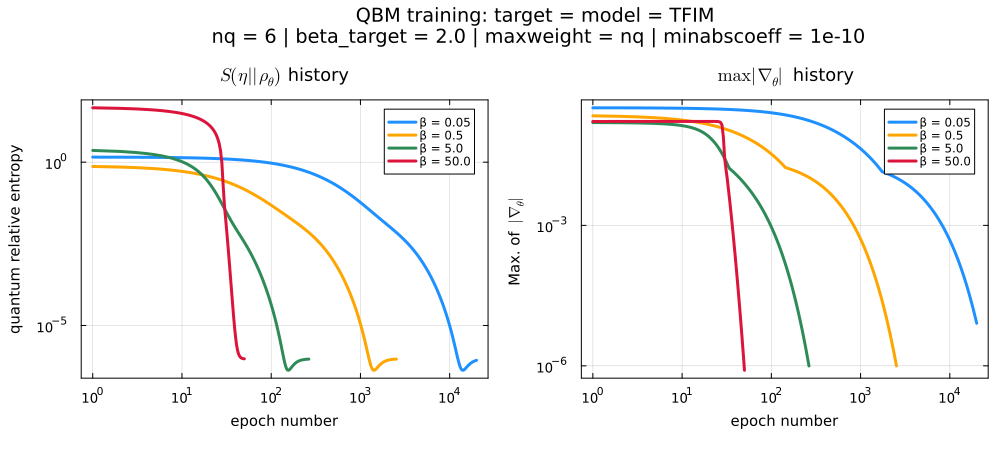

In [54]:
# ----------------------------- #
#  ---  EXPERIMENT SETUP   ---  #
# ----------------------------- #

nq = 6 

# target
## target hamiltonian
target_beta = 2
target_wij_xyz = (0.0, 0.0, 0.346)
target_wi_xyz = (-0.822, 0.0, 0.0)
params_target = HamiltonianParams(nq; 
                                    wi_xyz=target_wi_xyz, wij_xyz=target_wij_xyz) 
target_tfim_paulis = makehamiltonian(params_target; 
                                        connectivity=:nearest, periodic=false) * target_beta
target_tfim_matrix = paulistringtomatrix(target_tfim_paulis)
## target state
targert_circuit, target_theta = paulistringtocircuit(target_tfim_paulis)
num_layers_target = 100
max_weight_target = nq
min_abs_coeff_target = 1e-20
target_eta = makethermalstate(nq, targert_circuit, target_theta, num_layers_target; 
                                max_weight=max_weight_target, min_abs_coeff=min_abs_coeff_target)
target_eta_matrix = paulistringtomatrix(target_eta)

# beta values 
beta_values = [0.05, 0.5, 5, 50]
colors = [:dodgerblue, :seagreen, :orange, :crimson]

# learning rate
gamma = 0.2
# number of epochs
epochs = 20000
# stop when gradient is smaller than epsilon
epsilon = 1e-6

# Output path
save_dir = "/Users/micheleminervini/Desktop/PauliSampling.jl/numerics/quantumboltzmannmachines/data"
base_name = "targetTFIM_qbmTFIM_6qb_notrunc"

# ----------------------------- #
#  ---  INITIALIZE PLOTS   ---  #
# ----------------------------- #

# storage for plots
p1 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "quantum relative entropy",
    title = "\n" * "\n" * string(L"S\left(\!\eta || \!\rho\!_\theta\!\right)", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

p2 = plot(
    yaxis = :log10,
    xaxis = :log10,
    xlabel = "epoch number",
    ylabel = "Max. of  " * L"|\!\nabla\!_\theta|",
    title = "\n" * "\n" * string(L"\max |\!\nabla\!_\theta|", " history"),
    legend = :topright,
    lw = 3,
    titlefont = font(12),
    guidefont = font(10),
    tickfont = font(9),
    margin = 5mm
)

# ----------------------------- #
#  ---  MAIN OPTIMIZATION   --- #
# ----------------------------- #

# Loop over β values
for (i, beta) in enumerate(beta_values)

    println("\n" * "="^60)
    @printf("Starting optimization for β = %.3f\n", beta)
    println("="^60)

    # QBM model
    rng = MersenneTwister(1)
    jz = randn(rng)
    bx = randn(rng)
    j = (0.0, 0.0, jz)
    b = (-bx, 0.0, 0.0)
    params = HamiltonianParams(nq; wi_xyz=b, wij_xyz=j)
    ## truncation parameters
    num_layers_qbm = 100
    max_weight_qbm = nq
    min_abs_coeff_qbm = 1e-10

    # keep track of loss and gradients
    qre_hist = Float64[]
    grad_hist = Vector{Float64}[]

    for epoch in 1:epochs
        qbm_tfim_paulis = makehamiltonian(params; connectivity=:nearest, periodic=false) * beta
        qbm_tfim_matrix = paulistringtomatrix(qbm_tfim_paulis)
        push!(qre_hist, computequantumrelativeentropy(target_eta_matrix, target_probs, qbm_tfim_matrix))

        # create qbm state
        circuit, theta = paulistringtocircuit(qbm_tfim_paulis)
        rho = makethermalstate(nq, circuit, theta, num_layers_qbm;
                                        max_weight=max_weight_qbm,
                                        min_abs_coeff=min_abs_coeff_qbm)
        rho_matrix = paulistringtomatrix(rho)

        # Compute and record gradient
        grads = computegradients(params, target_eta, rho)
        flat_grads = vcat(
            reduce(vcat, grads.wi_xyz)...,
            reduce(vcat, [vec(g) for g in grads.wij_xyz])...
        )
        push!(grad_hist, abs.(flat_grads))

        # Update parameters
        updateparameters!(params, grads, gamma)

        # Print diagnostics every 100 epochs
        if epoch % 100 == 0
            @printf("  [β=%.2f | epoch=%4d]  QRE = %.6e   max|∇| = %.6e\n",
                    beta, epoch, qre_hist[end], maximum(grad_hist[end]))
        end

        # Stop if converged
        if maximum(grad_hist[end]) < epsilon
            println("Converged: max gradient < epsilon")
            break
        end
    end

    # Summary for this β
    @printf("\nFinished β = %.3f  → epochs: %d | final QRE = %.6e | final max|∇| = %.3e\n",
            beta, length(qre_hist), qre_hist[end], maximum(grad_hist[end]))
    println("-"^60)

    # ------------------------- #
    # --- SAVE DATA TO FILE --- #
    # ------------------------- #

    # Save optimization histories as CSV
    df = DataFrame(epoch = 1:length(qre_hist),
                   qre = qre_hist,
                   max_grad = [maximum(g) for g in grad_hist])
    csv_path = joinpath(save_dir, "$(base_name)_beta$(beta).csv")
    CSV.write(csv_path, df)
    @printf("  → Saved CSV data to %s\n", csv_path)

    # Collect metadata only once per run
    metadata = Dict(
        "timestamp" => string(now()),
        "model_target" => "TFIM",
        "model_qbm" => "TFIM",
        "n_qubits" => nq,
        "beta_target" => target_beta,
        "beta_qbm" => beta,
        "beta_values" => beta_values,
        "learning_rate" => gamma,
        "epochs" => epochs,
        "epsilon" => epsilon,
        "target_params" => Dict("wi_xyz" => params_target.wi_xyz,
                                "wij_xyz" => params_target.wij_xyz),
        "target_truncation" => Dict("max_weight" => max_weight_target,
                                    "min_abs_coeff" => min_abs_coeff_target,
                                    "num_layers" => num_layers_target),
        "qbm_truncation" => Dict("max_weight" => max_weight_qbm,
                                 "min_abs_coeff" => min_abs_coeff_qbm,
                                 "num_layers" => num_layers_qbm)
    )

    json_path = joinpath(save_dir, "$(base_name)_beta$(beta)_metadata.json")
    JSON3.write(json_path, metadata; indent=2)
    @printf("  → Saved metadata to %s\n", json_path)

    # ------------------------- #
    # --- ADD TO PLOTS --- #
    # ------------------------- #
    plot!(p1, qre_hist; label = "β = $(beta)", color = colors[i], lw = 3)
    plot!(p2, [maximum(g) for g in grad_hist];
          label = "β = $(beta)", color = colors[i], lw = 3)
end

# Combine plots side by side
combined = plot(
    p1, p2,
    layout = (1, 2),
    size = (1000, 450),
    plot_title = "QBM training: target = model = TFIM\n nq = 6 | beta_target = 2.0 | maxweight = nq | minabscoeff = 1e-10",
    plot_titlefont = font(13),
    bottom_margin = 9mm,  
    left_margin = 5mm,    
    right_margin = 1mm,
    top_margin = 10mm,
    framestyle = :box,
    titleloc = :center,
    spacing = 10mm
)

display(combined)